
# Exploring Convolutional Layers Through Data and Experiments

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

## 1. Dataset exploration (EDA)

Download the dataset from Kaggle (https://www.kaggle.com/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals) and place it in DB/animals relative to the repo.

In [ ]:
dataset_dir = "DB/animals"  # relative path

### Dataset size and class distribution

In [4]:
import os
from collections import Counter

class_counts = {}
total_images = 0

for root, dirs, files in os.walk(dataset_dir):
    if files:
        class_name = os.path.basename(root)
        num_images = len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        class_counts[class_name] = num_images
        total_images += num_images

print(f"Total images: {total_images}")
print(f"Total classes: {len(class_counts)}")

for cls, count in class_counts.items():
    print(f"{cls}: {count} images")

Total images: 5400
Total classes: 90
antelope: 60 images
badger: 60 images
bat: 60 images
bear: 60 images
bee: 60 images
beetle: 60 images
bison: 60 images
boar: 60 images
butterfly: 60 images
cat: 60 images
caterpillar: 60 images
chimpanzee: 60 images
cockroach: 60 images
cow: 60 images
coyote: 60 images
crab: 60 images
crow: 60 images
deer: 60 images
dog: 60 images
dolphin: 60 images
donkey: 60 images
dragonfly: 60 images
duck: 60 images
eagle: 60 images
elephant: 60 images
flamingo: 60 images
fly: 60 images
fox: 60 images
goat: 60 images
goldfish: 60 images
goose: 60 images
gorilla: 60 images
grasshopper: 60 images
hamster: 60 images
hare: 60 images
hedgehog: 60 images
hippopotamus: 60 images
hornbill: 60 images
horse: 60 images
hummingbird: 60 images
hyena: 60 images
jellyfish: 60 images
kangaroo: 60 images
koala: 60 images
ladybugs: 60 images
leopard: 60 images
lion: 60 images
lizard: 60 images
lobster: 60 images
mosquito: 60 images
moth: 60 images
mouse: 60 images
octopus: 60 ima

### Image dimensions and channels

In [5]:
from PIL import Image
import random

image_shapes = []

all_images = []
for root, _, files in os.walk(dataset_dir):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(root, f))

sample_images = random.sample(all_images, 10)

for img_path in sample_images:
    img = Image.open(img_path)
    image_shapes.append((img.size, img.mode))

for shape in image_shapes:
    print("Dimensions:", shape[0], "Mode:", shape[1])

Dimensions: (660, 373) Mode: RGB
Dimensions: (205, 246) Mode: RGB
Dimensions: (769, 581) Mode: RGB
Dimensions: (343, 147) Mode: RGB
Dimensions: (275, 183) Mode: RGB
Dimensions: (1200, 655) Mode: RGB
Dimensions: (318, 159) Mode: RGB
Dimensions: (251, 201) Mode: RGB
Dimensions: (754, 566) Mode: RGB
Dimensions: (2000, 1335) Mode: RGB


The images in the dataset are in color, with three channels (RGB). However, the dimensions vary significantly between samples, with resolutions ranging from approximately 200×170 pixels to over 2000×1000 pixels.

This variability makes a resizing process necessary before training, in order to ensure consistent inputs for the convolutional network.

In [6]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

As part of preprocessing, the images are resized to 224×224 pixels, converted to tensors, and normalized. This allows for stable training and makes it easier to compare different convolutional architectures.

### Example images from different classes (random selection of 9)

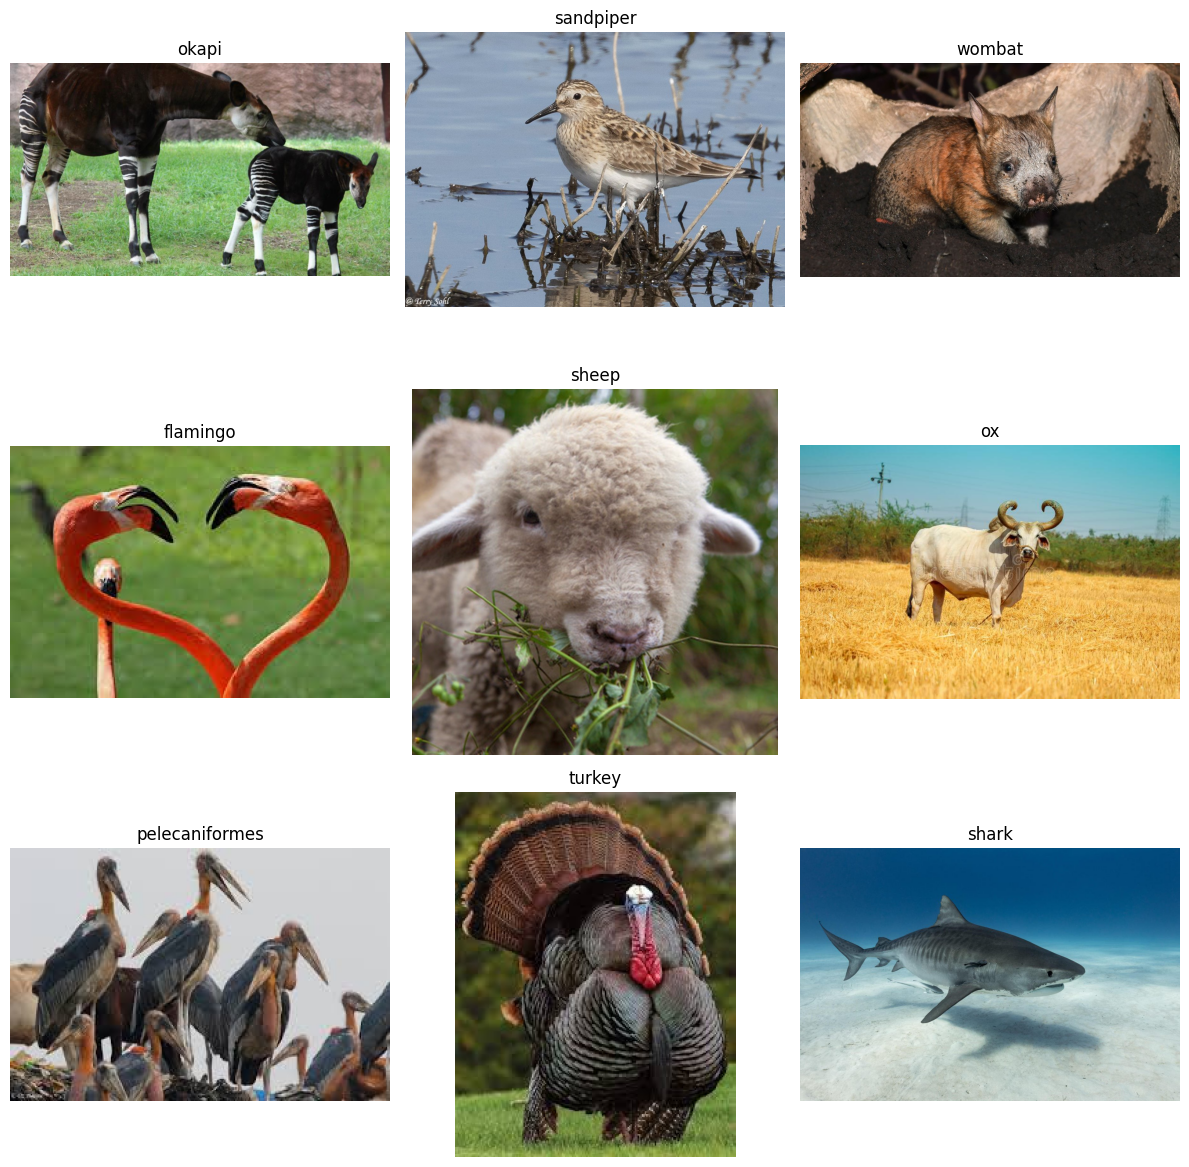

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

dataset_dir = "DB/animals"  # relative path

subfolders = [os.path.join(dataset_dir, f) for f in os.listdir(dataset_dir) 
              if os.path.isdir(os.path.join(dataset_dir, f))]

selected_folders = random.sample(subfolders, 9)

plt.figure(figsize=(12, 12))

for i, folder in enumerate(selected_folders):
    images = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    img_name = random.choice(images)
    img_path = os.path.join(folder, img_name)
    img = Image.open(img_path)
    
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(os.path.basename(folder))
    plt.axis("off")

plt.tight_layout()
plt.show()
